# Temas Tratados en el Trabajo Práctico 8

* Aprendizaje estadístico.

* Evolución de la verosimilitud de una hipótesis en función de observaciones.

* Aprendizaje no supervisado. Algoritmo K-means.

* Aprendizaje supervisado. Algoritmo Knn.

* Aprendizaje por refuerzo. Algoritmo Q-Learning.

## Ejercicios Teóricos

1. Un fabricante de tornillos vende cajas que contienen 1000 tornillos de cabeza redonda con tres tipos de recubrimiento electrolítico (cincado, cobre y níquel). Cada caja se rellena
con diferentes proporciones que pueden variar de la siguiente manera:

&emsp;&emsp;a: Todos los tornillos están recubiertos de níquel. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;b: El 70% de los tornillos están recubiertos de níquel, el 20% de cobre, el resto está cincado. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;c: El 50% de los tornillos están recubiertos de níquel, el 25% de cobre y el resto está cincado. 50 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;d: El 20 % de los tornillos están recubiertos de níquel, el 50% de cobre y el resto está cincado. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;e: Todos los tornillos están recubiertos de cobre. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;1.1 ¿Cuál es la distribución a priori sobre las hipótesis?

### Resolución

Cada hipótesis representa un tipo de caja. La **probabilidad a priori** indica qué tan probable es elegir una caja de ese tipo antes de observar los tornillos.

Las proporciones de fabricación y la composición de cada caja son:

| Hipótesis | Níquel | Cobre | Cincado | Probabilidad a priori |
|:---------:|:------:|:-----:|:------:|:---------------------:|
| $h_a$ | 100 % | 0 % | 0 % | 0.15 |
| $h_b$ | 70 % | 20 % | 10 % | 0.15 |
| $h_c$ | 50 % | 25 % | 25 % | 0.50 |
| $h_d$ | 20 % | 50 % | 30 % | 0.10 |
| $h_e$ | 0 % | 100 % | 0 % | 0.10 |

Por lo tanto, la distribución a priori es:

$$
\boxed{P(H)=\langle 0.15,\;0.15,\;0.50,\;0.10,\;0.10\rangle}
$$

Se verifica que:

$$
0.15+0.15+0.50+0.10+0.10=1
$$

Inicialmente, la hipótesis más probable es $h_c$, porque corresponde al 50 % de las cajas fabricadas.

**Supuesto utilizado:** siguiendo la presentación, consideramos las observaciones independientes e idénticamente distribuidas. Esto es exacto si se extrae con reposición y aproximado si no se devuelven los tornillos, ya que se observan solamente 10 de los 1000 tornillos de la caja.

&emsp;Considerando que los 10 primeros tornillos que se extraen de una caja de muestra son de cobre:

&emsp;&emsp;1.2 Calcule la probabilidad de cada hipótesis dado que los 10 primeros tornillos fueron de cobre.

### Resolución

Observamos que los **primeros diez tornillos extraídos son de cobre**. Queremos calcular qué tan probable es cada tipo de caja después de conocer este resultado.

Utilizamos estos símbolos:

- $h_i$: la hipótesis de que la caja pertenece al tipo $i$, donde $i$ puede ser a, b, c, d o e.
- $D_{10}$: el resultado observado, es decir, diez tornillos de cobre consecutivos.
- $P(h_i)$: probabilidad inicial de ese tipo de caja.
- $P(D_{10}\mid h_i)$: probabilidad de obtener diez tornillos de cobre si la caja es de ese tipo. Se llama **verosimilitud**.
- $P(h_i\mid D_{10})$: probabilidad actualizada de ese tipo de caja después de observar los diez tornillos. Se llama **probabilidad posterior**.

El símbolo $\mid$ se lee “dado que” o “sabiendo que”.

### 1. Probabilidad de observar diez tornillos de cobre

Como las extracciones son con reposición, la probabilidad de obtener cobre no cambia entre una extracción y otra.

Por ejemplo, en una caja del tipo b, cada extracción tiene una probabilidad de 0.20 de dar un tornillo de cobre. Para obtener diez seguidos:

$$
P(D_{10}\mid h_b)
=
\underbrace{0.20\times0.20\times\cdots\times0.20}_{10\text{ extracciones}}
=
(0.20)^{10}
$$

Hacemos lo mismo para los demás tipos de caja:

| Tipo de caja | Probabilidad de obtener cobre en una extracción | Probabilidad de obtener diez de cobre seguidos |
|:------------:|:----------------------------------------------:|:----------------------------------------------:|
| a | $0$ | $0^{10}=0$ |
| b | $0.20$ | $(0.20)^{10}=0.0000001024$ |
| c | $0.25$ | $(0.25)^{10}\approx0.000000953674$ |
| d | $0.50$ | $(0.50)^{10}=0.0009765625$ |
| e | $1$ | $1^{10}=1$ |

### 2. Actualización mediante el teorema de Bayes

El teorema de Bayes combina la probabilidad inicial de cada tipo de caja con la probabilidad de obtener los datos observados:

$$
P(h_i\mid D_{10})
=
\frac{P(D_{10}\mid h_i)\,P(h_i)}
{P(D_{10})}
$$

El denominador $P(D_{10})$ es la probabilidad total de obtener diez tornillos de cobre, considerando todos los tipos de caja:

$$
\begin{aligned}
P(D_{10})={}&
0^{10}(0.15)
+(0.20)^{10}(0.15)
+(0.25)^{10}(0.50)\\
&+(0.50)^{10}(0.10)
+1^{10}(0.10)
\end{aligned}
$$

$$
P(D_{10})\approx0.100098148447
$$

Dividir por este valor permite que las probabilidades actualizadas sumen 1.

Por ejemplo, para una caja del tipo e:

$$
P(h_e\mid D_{10})
=
\frac{1^{10}(0.10)}{0.100098148447}
\approx0.99901948
$$

### 3. Resultados

| Tipo de caja | Probabilidad después de observar diez tornillos de cobre |
|:------------:|:-------------------------------------------------------:|
| a | 0 % |
| b | 0.00001534 % |
| c | 0.00047637 % |
| d | 0.09756050 % |
| e | 99.90194779 % |

**Conclusión:** la caja es del tipo e con una probabilidad aproximada de **99.902 %**.

Al principio, el tipo c era el más probable por ser el más fabricado. Sin embargo, obtener diez tornillos de cobre consecutivos favorece fuertemente al tipo e, porque todas sus piezas son de cobre.

El tipo a queda descartado desde la primera extracción de cobre, ya que contiene únicamente tornillos de níquel.


&emsp;&emsp;1.3 Grafique la evolución de la verosimilitud de cada hipótesis en función del número de tornillos extraídos de la caja.

### Resolución

Queremos observar qué ocurre a medida que extraemos tornillos y todos resultan ser de cobre.

Llamamos:

- $n$: cantidad de tornillos extraídos.
- $D_n$: resultado de haber obtenido $n$ tornillos de cobre consecutivos.
- $h_i$: hipótesis de que la caja pertenece al tipo $i$.

El valor $n=0$ representa la situación inicial, antes de extraer tornillos.

Debemos distinguir dos cantidades:

### Verosimilitud: probabilidad de los datos para cada tipo de caja

$$
P(D_n\mid h_i)
=
\left[P(\text{cobre}\mid h_i)\right]^n
$$

Responde a la pregunta:

**“Si la caja fuera de este tipo, ¿qué probabilidad habría de obtener estos resultados?”**

Por ejemplo, para el tipo d:

$$
P(D_n\mid h_d)=(0.50)^n
$$

Antes de observar tornillos, la verosimilitud vale 1 para todas las hipótesis.

### Probabilidad posterior: probabilidad actualizada de cada tipo de caja

$$
P(h_i\mid D_n)
=
\frac{P(D_n\mid h_i)\,P(h_i)}
{\sum_j P(D_n\mid h_j)\,P(h_j)}
$$

El símbolo $\sum_j$ indica que sumamos los términos correspondientes a los cinco tipos de caja.

Esta probabilidad responde a la pregunta:

**“Después de obtener estos resultados, ¿qué tan probable es que la caja sea de este tipo?”**

El primer gráfico muestra la **verosimilitud**, como solicita el enunciado. El segundo muestra la **probabilidad posterior**, para visualizar cómo se actualizan las hipótesis mediante el aprendizaje bayesiano.

Probabilidades después de observar 10 tornillos de cobre:

h_a: 0.000000000000 (0.00000000 %)
h_b: 0.000000153449 (0.00001534 %)
h_c: 0.000004763696 (0.00047637 %)
h_d: 0.000975604959 (0.09756050 %)
h_e: 0.999019477896 (99.90194779 %)

Suma de las probabilidades: 1.000000


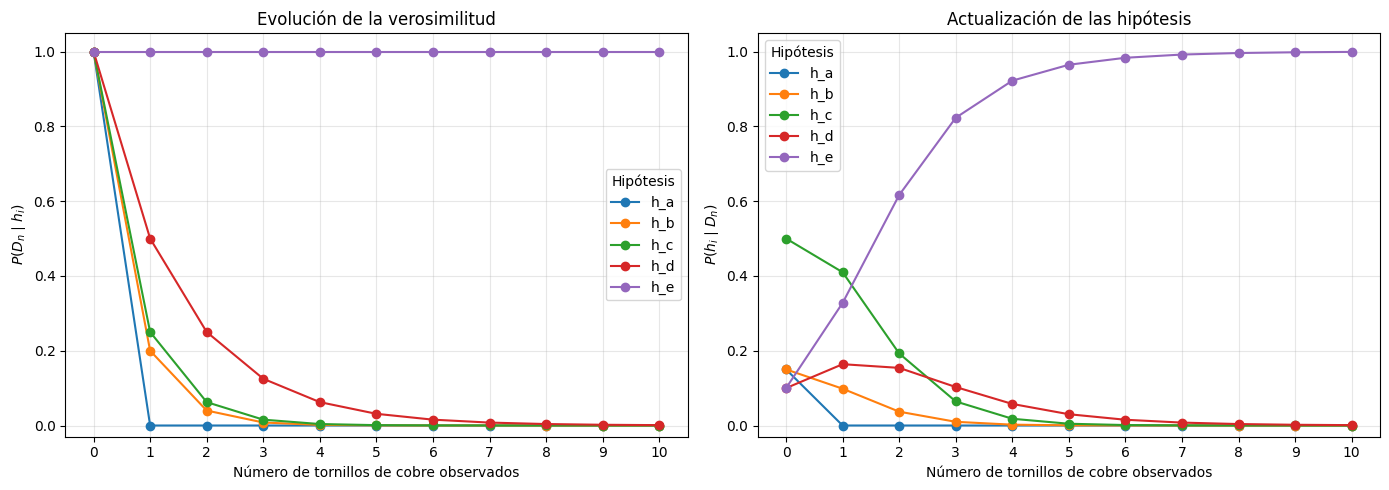

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Hipótesis, probabilidades iniciales y proporción de cobre.
hipotesis = ["h_a", "h_b", "h_c", "h_d", "h_e"]
priori = np.array([0.15, 0.15, 0.50, 0.10, 0.10])
prob_cobre = np.array([0.00, 0.20, 0.25, 0.50, 1.00])

# Incluimos n = 0 para representar la situación sin observaciones.
numero_tornillos = np.arange(11)

# Cada fila corresponde a una cantidad de observaciones.
verosimilitudes = np.ones((11, 5))

# Si todos los tornillos observados son de cobre:
# P(D_n | h_i) = P(cobre | h_i) ** n.
for n in numero_tornillos[1:]:
    verosimilitudes[n] = prob_cobre ** n

# Aplicamos Bayes: multiplicamos por la priori y normalizamos.
pesos = verosimilitudes * priori
evidencias = pesos.sum(axis=1, keepdims=True)
posteriores = pesos / evidencias

# Mostramos los resultados del inciso 1.2.
print("Probabilidades después de observar 10 tornillos de cobre:\n")

for nombre, probabilidad in zip(hipotesis, posteriores[10]):
    print(f"{nombre}: {probabilidad:.12f} ({100 * probabilidad:.8f} %)")

print(f"\nSuma de las probabilidades: {posteriores[10].sum():.6f}")

# Mostramos la verosimilitud y la probabilidad posterior por separado.
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
colores = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

for i, nombre in enumerate(hipotesis):
    ejes[0].plot(
        numero_tornillos,
        verosimilitudes[:, i],
        marker="o",
        color=colores[i],
        label=nombre,
    )

    ejes[1].plot(
        numero_tornillos,
        posteriores[:, i],
        marker="o",
        color=colores[i],
        label=nombre,
    )

ejes[0].set_title("Evolución de la verosimilitud")
ejes[0].set_ylabel(r"$P(D_n \mid h_i)$")

ejes[1].set_title("Actualización de las hipótesis")
ejes[1].set_ylabel(r"$P(h_i \mid D_n)$")

for eje in ejes:
    eje.set_xlabel("Número de tornillos de cobre observados")
    eje.set_xticks(numero_tornillos)
    eje.set_ylim(-0.03, 1.05)
    eje.grid(alpha=0.3)
    eje.legend(title="Hipótesis")

plt.tight_layout()
plt.show()

### Interpretación de los gráficos

En el gráfico de **verosimilitud**:

- $h_a$ pasa a cero desde la primera observación, porque no contiene cobre.
- Para las cajas mixtas, la probabilidad de observar únicamente cobre disminuye al aumentar la cantidad de extracciones.
- $h_e$ mantiene una verosimilitud igual a 1, porque todos sus tornillos son de cobre.

En el gráfico de **probabilidades posteriores**:

- En $n=0$ aparecen las probabilidades a priori.
- $h_e$ aumenta progresivamente hasta acercarse a 1.
- Algunas hipótesis mixtas pueden aumentar inicialmente, pero pierden probabilidad cuando se acumulan más observaciones de cobre.

Esto muestra cómo funciona el **aprendizaje bayesiano**: combinamos las probabilidades iniciales con los datos observados para actualizar la probabilidad de cada hipótesis.

&emsp;&emsp;1.4 Para cada hipótesis, ¿cuál es la probabilidad de que el cuarto tornillo extraído sea de cobre?

### Resolución

Para cada tipo de caja, queremos conocer la probabilidad de que **el cuarto tornillo extraído sea de cobre**.

Llamamos $C_4$ al evento “el cuarto tornillo es de cobre”.

Como trabajamos con reposición, la composición de la caja no cambia. Por eso, para un tipo de caja conocido, la probabilidad de obtener cobre es la misma en la primera, segunda, tercera o cuarta extracción.

| Tipo de caja | Probabilidad de que el cuarto tornillo sea de cobre |
|:------------:|:--------------------------------------------------:|
| a | 0 % |
| b | 20 % |
| c | 25 % |
| d | 50 % |
| e | 100 % |

Por ejemplo:

$$
P(C_4\mid h_b)=0.20
$$

Se lee: “La probabilidad de que el cuarto tornillo sea de cobre, sabiendo que la caja es del tipo b, es del 20 %”.

**Estas probabilidades corresponden a cada tipo de caja conocido.** Las probabilidades del inciso 1.2 responden a otra pregunta: qué tipo de caja tenemos después de observar diez tornillos de cobre.

2. ¿Qué diferencia principal existe entre un algoritmo supervisado y un algoritmo no supervisado?

## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

3. Genere un conjunto de 23 puntos que contengan coordenadas *xy* aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos en un gráfico.

&emsp;&emsp;3.1 Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.


&emsp;&emsp;3.2 Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo Knn. Utilice distintos valores de K y anote lo que observa con esta elección.

4. La imagen mostrada abajo muestra una red de salas y cómo se comunican entre ellas. Implemente un algoritmo Q-Learning con un factor despreciativo $γ = 0.9$. La matriz de recompensas debe asignar un valor de 0 a cada camino accesible y un valor de 100 a caminos que lleven a la sala del tesoro.

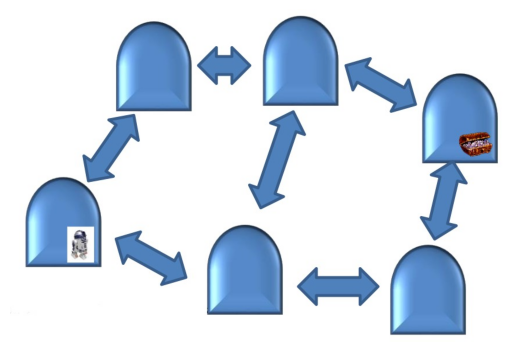

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1dkDruEIPa7f-BAmjI47TZl3bxaqYf6a9"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

&emsp;&emsp;4.1 Dibuje un diagrama con la asignación de recompensas correspondiente a cada estado.

&emsp;&emsp;4.2 Diseñe y muestre la matriz de recompensas.

&emsp;&emsp;4.3 Obtenga la matriz Q óptima, normalícela respecto al valor máximo encontrado y grafique la política obtenida en el diagrama mostrado inicialmente.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2017) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)